In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pykrige.uk import UniversalKriging
from scipy.stats import norm

d = pd.read_csv('../data/data PM10 mean 2025.csv', sep=";")

# Filtrer la France métropolitaine
d_metro = d[
    (d["validité"] == 1) &
    (d["Latitude"].between(41.0, 51.5)) &
    (d["Longitude"].between(-5.5, 10.0))
].dropna(subset=["Latitude", "Longitude", "valeur"])

lons = d_metro["Longitude"].values
lats = d_metro["Latitude"].values
vals = d_metro["valeur"].values

grid_lon = np.linspace(-5.5, 10.0, 100)
grid_lat = np.linspace(41.0, 51.5, 100)
seuil_oms = 15.0

UK = UniversalKriging(
    lons, lats, vals,
    variogram_model="spherical",
    drift_terms=["regional_linear"],
    nlags=43,
    anisotropy_scaling=1.5,
    anisotropy_angle=0,
    verbose=False,
    enable_plotting=False
)

z_pred, z_var = UK.execute("grid", grid_lon, grid_lat)
z_std = np.sqrt(z_var)

## Test de normaltié des prédictions

Shapiro-Wilk Test
Statistic : 0.9969
p-value   : 0.8413
-> Normality not rejected (p > 0.05)


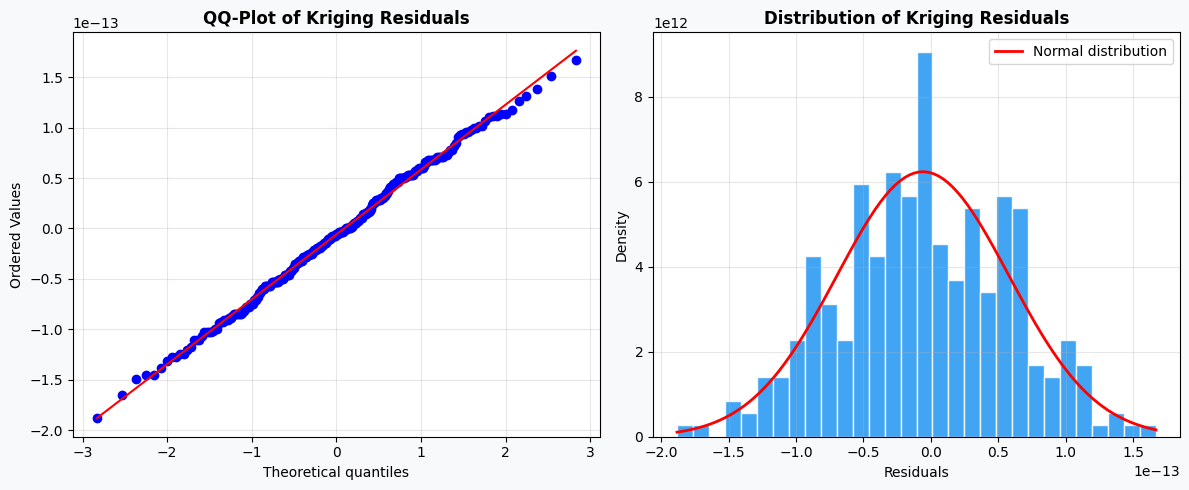

In [2]:
from scipy import stats
import matplotlib.pyplot as plt

# ============================================================
# 1. SHAPIRO-WILK TEST
# ============================================================

# Residuals = observed values - predicted values at stations
UK_full = UniversalKriging(
    lons, lats, vals,
    variogram_model="spherical",
    drift_terms=["regional_linear"],
    nlags=43,
    anisotropy_scaling=1.5,
    anisotropy_angle=0,
    verbose=False,
    enable_plotting=False
)

z_stations, _ = UK_full.execute("points", lons, lats)
residuals = vals - z_stations

stat, p_value = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test")
print(f"Statistic : {stat:.4f}")
print(f"p-value   : {p_value:.4f}")
if p_value > 0.05:
    print("-> Normality not rejected (p > 0.05)")
else:
    print("-> Normality rejected (p < 0.05)")

# ============================================================
# 2. QQ-PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#f8f9fa')

# QQ-plot
ax = axes[0]
ax.set_facecolor('white')
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("QQ-Plot of Kriging Residuals", fontweight='bold')
ax.grid(alpha=0.3)

# Residuals histogram
ax2 = axes[1]
ax2.set_facecolor('white')
ax2.hist(residuals, bins=30, color='#2196F3', edgecolor='white', alpha=0.85, density=True)
x = np.linspace(residuals.min(), residuals.max(), 100)
ax2.plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()),
         'r-', linewidth=2, label='Normal distribution')
ax2.set_title("Distribution of Kriging Residuals", fontweight='bold')
ax2.set_xlabel("Residuals")
ax2.set_ylabel("Density")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("normalite_residus.png", dpi=200, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# Carte des risques

In [3]:
prob_depassement = 1 - norm.cdf((seuil_oms - z_pred) / z_std)

var_90 = np.quantile(z_pred, 0.90)
var_95 = np.quantile(z_pred, 0.95)
var_99 = np.quantile(z_pred, 0.99)

print(f"Spatial VaR 90% : {var_90:.2f} µg/m³")
print(f"Spatial VaR 95% : {var_95:.2f} µg/m³")
print(f"Spatial VaR 99% : {var_99:.2f} µg/m³")
print(f"% grille > seuil OMS : {(z_pred > seuil_oms).mean()*100:.1f}%")

Spatial VaR 90% : 15.94 µg/m³
Spatial VaR 95% : 16.28 µg/m³
Spatial VaR 99% : 16.85 µg/m³
% grille > seuil OMS : 50.8%


C:\Users\jerem\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


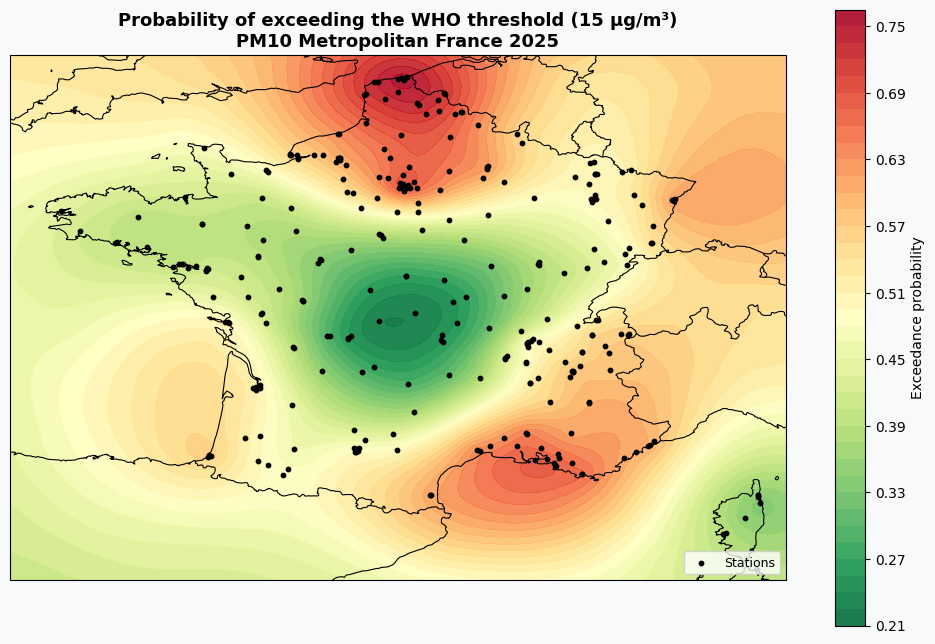

In [5]:
fig, ax = plt.subplots(figsize=(10, 8),
                        subplot_kw={'projection': ccrs.PlateCarree()})
fig.patch.set_facecolor('#f8f9fa')

ax.set_extent([-5.5, 10.0, 41.0, 51.5])
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='#f5f5f5')

cf = ax.contourf(grid_lon, grid_lat, prob_depassement, levels=50,
                  cmap="RdYlGn_r", transform=ccrs.PlateCarree(), alpha=0.9)
ax.scatter(lons, lats, c="black", s=10, transform=ccrs.PlateCarree(), zorder=5, label="Stations")
plt.colorbar(cf, ax=ax, label="Exceedance probability", shrink=0.8)

ax.set_title("Probability of exceeding the WHO threshold (15 µg/m³)\nPM10 Metropolitan France 2025",
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()